<a href="https://colab.research.google.com/github/shubhechhuk/40-days-da/blob/main/Diamond_prince.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [9]:
!pip install statsmodels


In [10]:
!pip install scikit-learn

In [11]:
from google.colab import files
uploaded = files.upload()

Saving diamonds.csv to diamonds (1).csv


In [12]:
df=pd.read_csv('diamonds.csv')

In [13]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


<Axes: xlabel='carat', ylabel='Count'>

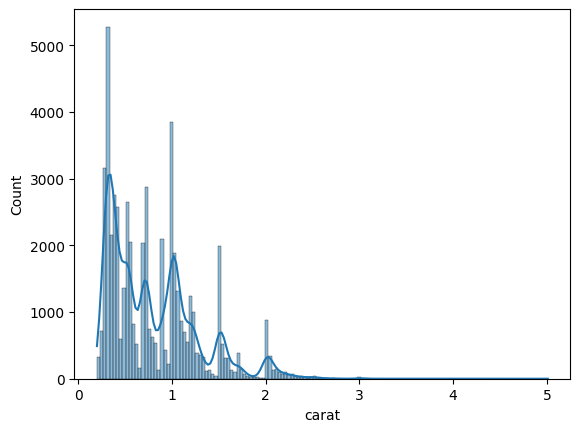

In [15]:
sns.histplot(df['carat'],kde=True)

<Axes: ylabel='carat'>

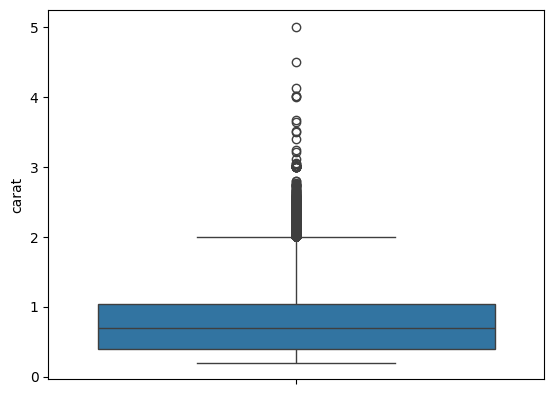

In [16]:
sns.boxplot(df['carat'])

<Axes: xlabel='price', ylabel='Count'>

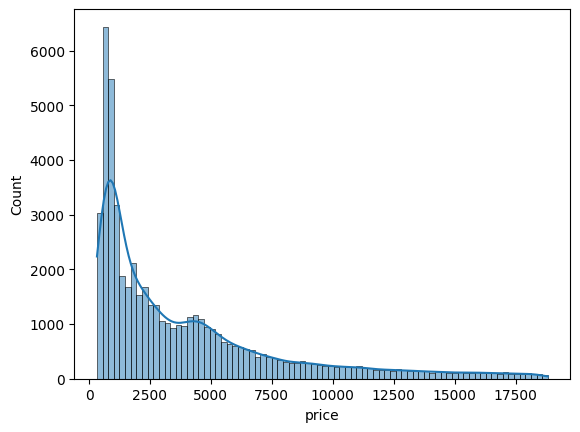

In [17]:
sns.histplot(df['price'],kde=True)

<Axes: ylabel='price'>

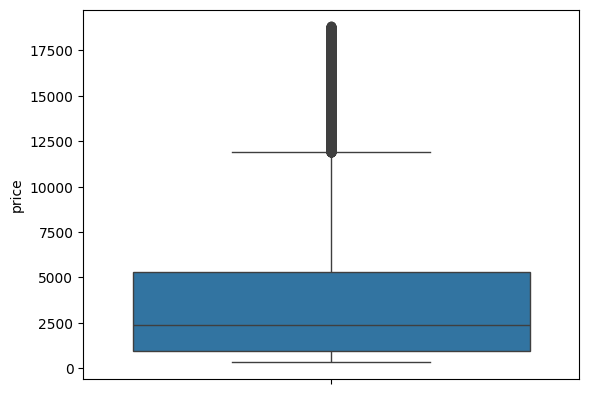

In [18]:
sns.boxplot(df['price'])

In [19]:
df['carat'].duplicated().sum()

np.int64(53667)

In [20]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17


In [21]:
df_unique_carat = df.drop_duplicates(subset='carat')


In [22]:
df['carat'].nunique()



273

In [23]:
df.duplicated(subset=['carat', 'price']).sum()


np.int64(24952)

In [24]:
df = df.drop_duplicates(subset=['carat', 'price'])


<Axes: xlabel='carat', ylabel='Count'>

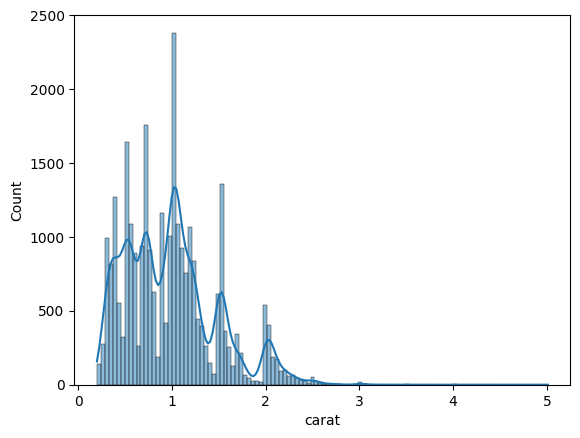

In [25]:
sns.histplot(df['carat'],kde=True)

<Axes: ylabel='carat'>

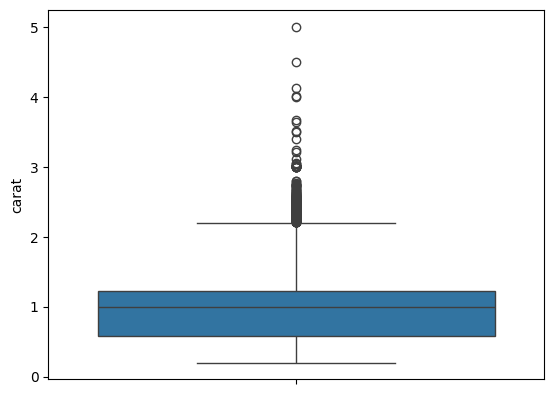

In [26]:
sns.boxplot(df['carat'])

<Axes: ylabel='price'>

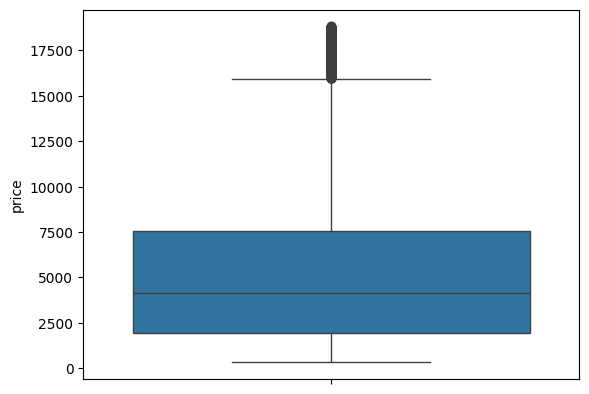

In [27]:
sns.boxplot(df['price'])

In [28]:
Q1 = df['carat'].quantile(0.25)
Q3 = df['carat'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['carat'] < (Q1 - 1.5*IQR)) | (df['carat'] > (Q3 + 1.5*IQR)))]

<Axes: ylabel='carat'>

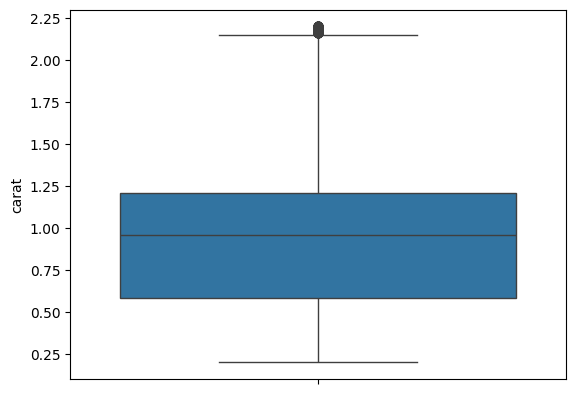

In [29]:
sns.boxplot(df['carat'])

<Axes: xlabel='carat', ylabel='Count'>

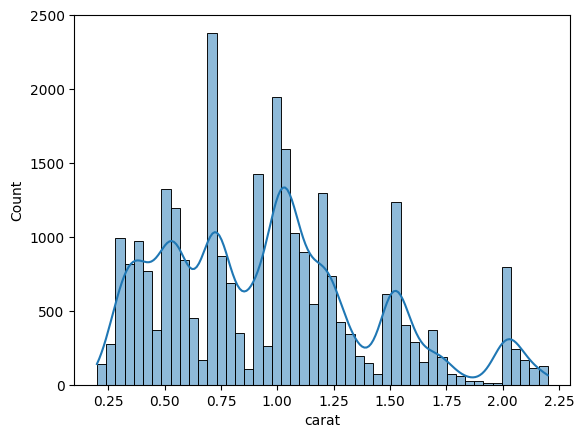

In [30]:
sns.histplot(df['carat'],kde=True)

In [31]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['price'] < (Q1 - 1.5*IQR)) | (df['price'] > (Q3 + 1.5*IQR)))]

<Axes: xlabel='price', ylabel='Count'>

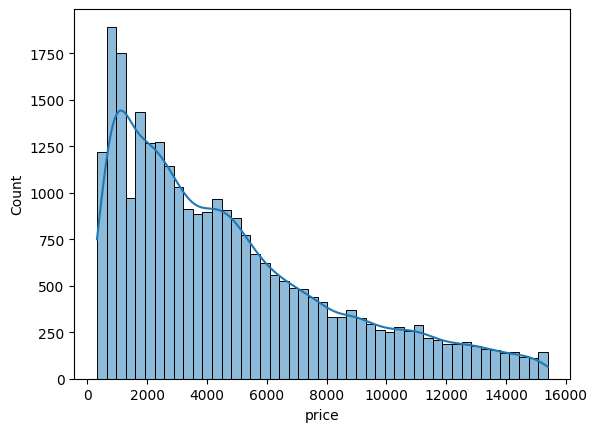

In [32]:
sns.histplot(df['price'],kde=True)

<Axes: ylabel='price'>

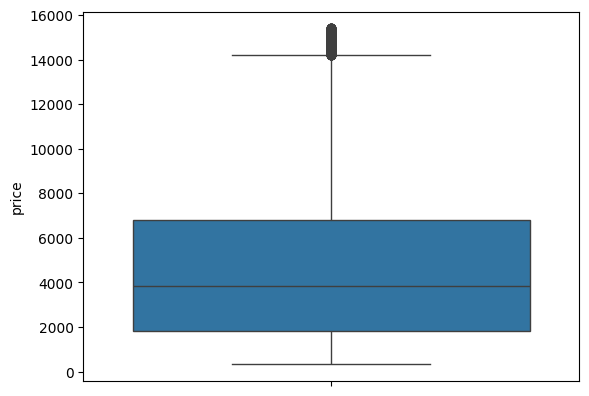

In [33]:
sns.boxplot(df['price'])

In [34]:
from sklearn.preprocessing import PowerTransformer

In [35]:
cols_to_transform = ['carat', 'price']


In [36]:
pt = PowerTransformer(method='yeo-johnson')

In [37]:
df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

<Axes: xlabel='carat', ylabel='Count'>

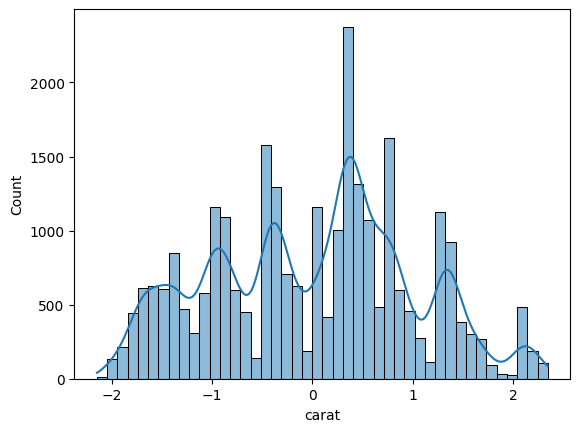

In [38]:
sns.histplot(df["carat"],kde=True)

<Axes: xlabel='price', ylabel='Count'>

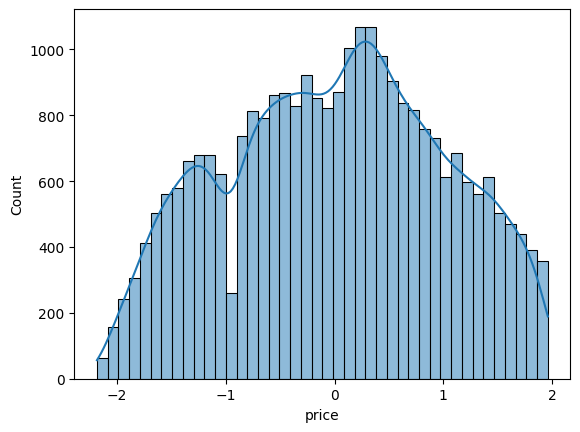

In [39]:
sns.histplot(df["price"],kde=True)

<Axes: xlabel='carat', ylabel='price'>

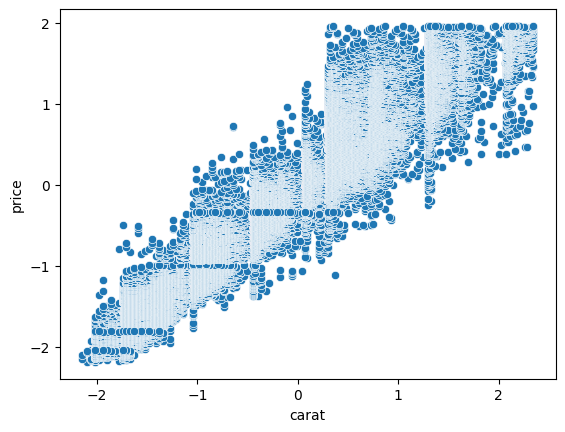

In [40]:
sns.scatterplot(x=df['carat'], y=df['price'])

In [41]:
corr = df['carat'].corr(df['price'])

In [42]:
print(corr)

0.9390812144570353


<Axes: xlabel='carat', ylabel='price'>

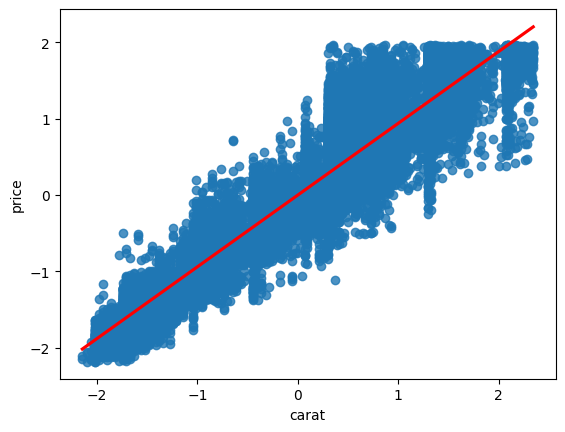

In [43]:
sns.regplot(x='carat', y='price', data=df, line_kws={"color":"red"})

In [44]:
x=df[['carat']]
y=df['price']

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [48]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [50]:
y_pred = model.predict(x_test)


In [52]:
from sklearn.metrics import mean_squared_error, r2_score

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


R² Score: 0.8828245729374404
Mean Squared Error: 0.11692077931234217


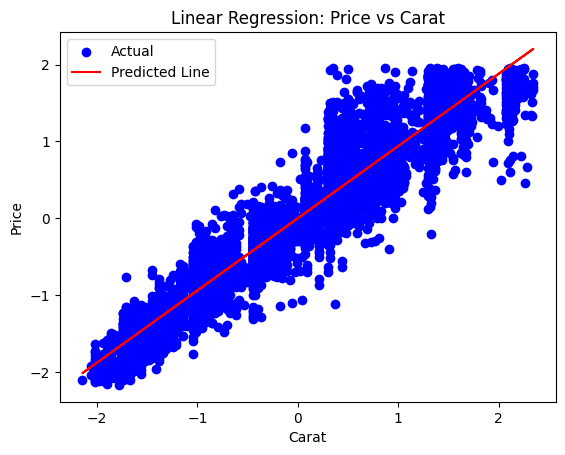

In [54]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.plot(x_test, y_pred, color='red', label='Predicted Line')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.title('Linear Regression: Price vs Carat')
plt.legend()
plt.show()


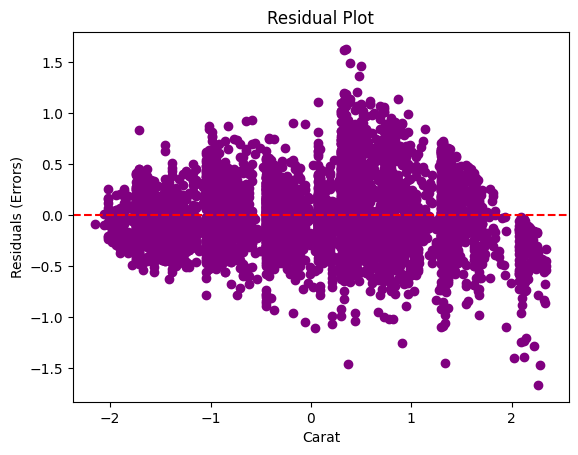

In [56]:
residuals = y_test - y_pred

plt.scatter(x_test, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Carat')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')
plt.show()


R² Score (Original Scale): 0.782122290725934
Mean Squared Error (Original Scale): 2879723.755279505


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


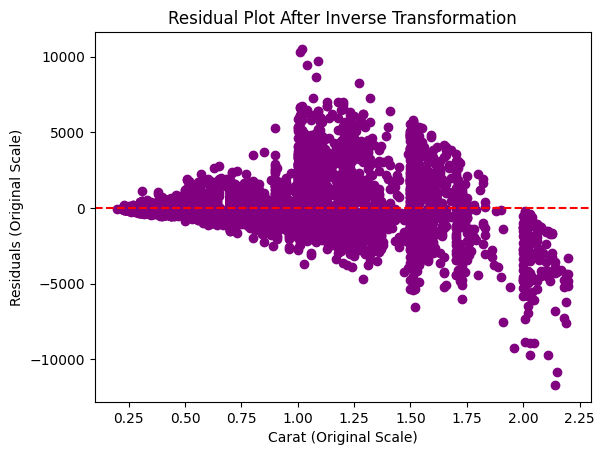

In [59]:
y_pred_transformed = model.predict(x_test)

# To inverse transform, we need to reconstruct the original input shape for the PowerTransformer.
# The PowerTransformer was fitted on ['carat', 'price'].
# x_test contains the transformed 'carat' values for the test set.
# y_test contains the transformed 'price' values for the test set.

# Create an array that combines x_test (transformed carat) and y_test (transformed price)
# for inverse transforming the actual values.
actual_transformed_data = np.hstack((x_test.values, y_test.values.reshape(-1, 1)))
actual_original_data = pt.inverse_transform(actual_transformed_data)
y_test_original = actual_original_data[:, 1] # 'price' is the second column

# Create an array that combines x_test (transformed carat) and y_pred_transformed (predicted transformed price)
# for inverse transforming the predicted values.
predicted_transformed_data = np.hstack((x_test.values, y_pred_transformed.reshape(-1, 1)))
predicted_original_data = pt.inverse_transform(predicted_transformed_data)
y_pred_original = predicted_original_data[:, 1] # 'price' is the second column

# Evaluate on the original scale
print("R² Score (Original Scale):", r2_score(y_test_original, y_pred_original))
print("Mean Squared Error (Original Scale):", mean_squared_error(y_test_original, y_pred_original))

# Residual Plot (in original scale)
# To plot residuals against original carat values, inverse transform x_test as well.
x_test_original = actual_original_data[:, 0] # 'carat' is the first column

residuals_original = y_test_original - y_pred_original
plt.scatter(x_test_original, residuals_original, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Carat (Original Scale)')
plt.ylabel('Residuals (Original Scale)')
plt.title('Residual Plot After Inverse Transformation')
plt.show()